In [1]:
from spacepy import pycdf

cdf = pycdf.CDF('data/Sept30_Storm/ace/ts2_l2_ace_def_20250927_v1.1.0.cdf')
ace_flux = cdf[f"ts2_l2_ace_def"][:]
ace_spect = ace_flux.sum(axis=-1)
ace_energies = cdf[f"ts2_l2_ace_energy"][:]
ace_time = cdf["Epoch"][:]
cdf.close()


In [2]:
import pandas as pd

df = pd.read_csv('output/Sept30_Storm_filtered.csv', parse_dates=['start_time', 'end_time'], index_col=0)
df

,start_time,end_time,Bx,By,Bz,score,file_name,B,cone_angle,clock_angle,label,aci_file,ead_file
index,,,,,,,,,,,,,
0,2025-09-27 01:21:19,2025-09-27 01:22:37,-1.936180,-4.495037,0.769296,0.663395,TracersDispersionEvent_TS2_2025-09-27T01:21:19...,4.954389,113.004350,279.711705,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250927_...,data/Sept30_Storm/ead/ts2_def_ead_20250927_v0....
5,2025-09-28 01:30:13,2025-09-28 01:31:32,-2.991730,4.040490,-4.695540,0.859231,TracersDispersionEvent_TS2_2025-09-28T01:30:13...,6.879252,115.778408,139.288158,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250928_...,data/Sept30_Storm/ead/ts2_def_ead_20250928_v0....
20,2025-09-28 16:02:20,2025-09-28 16:03:41,-1.384180,-10.228882,-3.035928,0.573218,TracersDispersionEvent_TS2_2025-09-28T16:02:20...,10.759314,97.391556,253.469133,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250928_...,data/Sept30_Storm/ead/ts2_def_ead_20250928_v0....
32,2025-09-30 11:28:56,2025-09-30 11:30:19,-8.338225,7.268442,-5.527518,0.688864,TracersDispersionEvent_TS2_2025-09-30T11:28:56...,12.365666,132.400167,127.252329,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250930_...,data/Sept30_Storm/ead/ts2_def_ead_20250930_v0....
34,2025-10-01 16:29:31,2025-10-01 16:30:54,-6.210000,5.120000,-3.450000,0.664833,TracersDispersionEvent_TS2_2025-10-01T16:29:31...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251001_...,data/Sept30_Storm/ead/ts2_def_ead_20251001_v0....
41,2025-10-02 11:47:46,2025-10-02 11:48:55,-6.210000,5.120000,-3.450000,0.768815,TracersDispersionEvent_TS2_2025-10-02T11:47:46...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251002_...,data/Sept30_Storm/ead/ts2_def_ead_20251002_v0....
42,2025-10-02 13:24:18,2025-10-02 13:25:22,-6.210000,5.120000,-3.450000,0.516902,TracersDispersionEvent_TS2_2025-10-02T13:24:18...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251002_...,data/Sept30_Storm/ead/ts2_def_ead_20251002_v0....
61,2025-10-03 23:09:40,2025-10-03 23:10:53,-6.210000,5.120000,-3.450000,0.250695,TracersDispersionEvent_TS2_2025-10-03T23:09:40...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251003_...,data/Sept30_Storm/ead/ts2_def_ead_20251003_v0....
64,2025-10-04 05:36:14,2025-10-04 05:37:22,-6.210000,5.120000,-3.450000,0.724066,TracersDispersionEvent_TS2_2025-10-04T05:36:14...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251004_...,data/Sept30_Storm/ead/ts2_def_ead_20251004_v0....


d = 15.79
Bs at satellite 44699.46130975912 nT
(49,) [11041.135     9843.519     8773.226     7818.317     6970.8345
  6210.886     5538.471     4933.6963    4400.5386    3923.084
  3493.3748    3115.3901    2777.1934    2474.8057    2204.248
  1965.5208    1754.6451    1563.6632    1392.5756    1241.3816
  1106.1028     986.7392     879.31195    783.821      700.26654
   620.6908     553.0514     493.3696     441.64536    393.89993
   350.13327    310.3454     278.5151     246.6848     222.81206
   198.93936    175.06664    155.1727     139.25755    123.3424
   111.40603     99.46968     87.53332     79.575745    71.618164
    63.660595    55.703014    47.74544     43.76666 ]


/tmp/ipykernel_1716/3794942415.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(new_xticklabels)


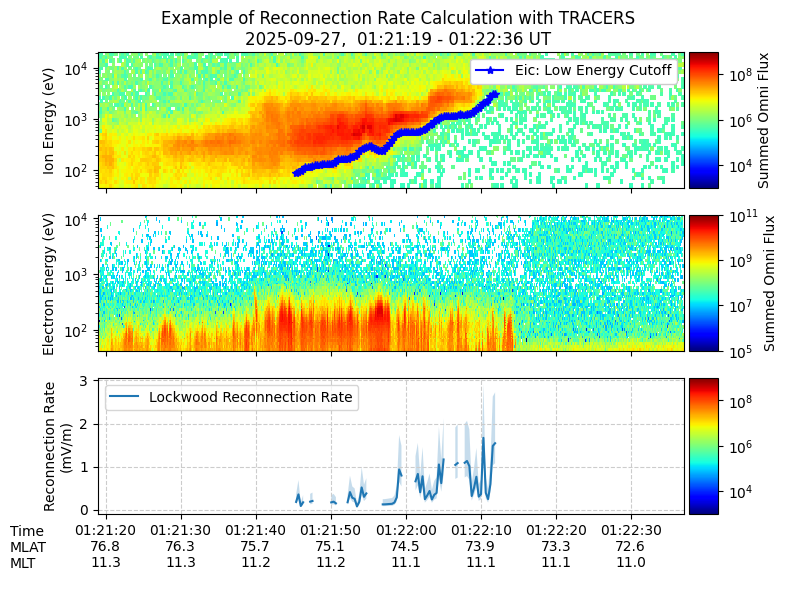

In [3]:
import lib_dasilva2026
from datetime import timedelta
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.dates import num2date
import importlib
import pylab as plt
import numpy as np
importlib.reload(lib_dasilva2026)

def get_d(i):
    with open(f'output/Sept30_Storm/dprime_{i}.txt', 'r') as fh:
        d = float(fh.read())
        print(f'd = {d:.2f}')
        return d

row = df.iloc[0]
d = get_d(0)


data = lib_dasilva2026.load_data(
    aci_file=row.aci_file,
    ead_file=row.ead_file,
)
subset_data = data.subset(row.start_time, row.end_time)
dispersion_stime = row.start_time
dispersion_etime = row.end_time - timedelta(seconds=25)
dispersion_subset = subset_data.subset(dispersion_stime, dispersion_etime)
Eic = dispersion_subset.find_Eic(Eic_frac=0.1)

recon_rate, err_low, err_high = dispersion_subset.calculate_recon_rate(
    alpha=0,
    d=d,
    Eic_frac=0.1,
    ascending=True,
)

# Do plotting -----------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
im = ax1.pcolor(
    subset_data.time,
    subset_data.energies[lib_dasilva2026.CHAN_CUTOFF:],
    subset_data.spect.T[lib_dasilva2026.CHAN_CUTOFF:],
    norm=LogNorm(vmin=lib_dasilva2026.SPECT_VMIN, vmax=lib_dasilva2026.SPECT_VMAX),
    cmap='jet',
)
ax1.plot(dispersion_subset.time, Eic, 'b*-', label='Eic: Low Energy Cutoff')
ax1.set_yscale('log')
ax1.set_ylabel('Ion Energy (eV)')
ax1.legend(loc='upper right', framealpha=1)

mask = (ace_time> row.start_time) & (ace_time < row.end_time)

im_e = ax2.pcolor(
    ace_time[mask],
    ace_energies,
    ace_spect[mask].T,
    norm=LogNorm(vmin=1e5, vmax=1e11),
    cmap='jet',
)
ax2.set_yscale('log')
ax2.set_ylabel('Electron Energy (eV)')

print(ace_energies.shape, ace_energies)

ax3.plot(dispersion_subset.time, recon_rate.value, label='Lockwood Reconnection Rate')
ax3.fill_between(dispersion_subset.time, err_low.value, err_high.value, alpha=0.25)
ax3.set_ylabel('Reconnection Rate\n(mV/m)')
ax3.grid(color='#ccc', linestyle='dashed')
plt.legend()

divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical').set_label(r'Summed Omni Flux')

divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im_e, cax=cax, orientation='vertical').set_label(r'Summed Omni Flux')

divider = make_axes_locatable(ax3)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical')

new_xticklabels = []

for xtick in ax3.get_xticks():
    time = num2date(xtick).replace(tzinfo=None)
    i = np.argmin(np.abs(subset_data.time - time))
    new_xticklabel = (
        time.strftime('%H:%M:%S') + '\n'
        + '%.1f' % subset_data.mlat[i] + '\n'
        + '%.1f' % subset_data.mlt[i] + '\n'
    )
    new_xticklabels.append(new_xticklabel)

ax3.set_xticklabels(new_xticklabels)
ax3.text(-0.15, -0.4, "Time\nMLAT\nMLT", transform=ax3.transAxes)


time_str = (
          f"{subset_data.time[0].strftime('%Y-%m-%d')},  "
          f"{subset_data.time[0].strftime('%H:%M:%S')} - {subset_data.time[-1].strftime('%H:%M:%S')} UT"
)

fig.suptitle(f'Example of Reconnection Rate Calculation with TRACERS\n{time_str}', y=0.95)
fig.savefig('plots/recon_rate_event.png', dpi=300, bbox_inches='tight')